# 03 — Baseline Anomaly Detection Models (Branch A)
**Li-ion Battery Degradation Anomaly Detection Using Deep Learning**

---

## Goals
1. Fix D2 naming convention (统一为 D2_Qual / D2_Subseq)
2. Implement 4 baseline methods from Diao et al. (2020)
 - One-Class SVM (OC-SVM)
 - Local Outlier Factor (LOF)
 - Mahalanobis Distance (MD)
 - Sequential Probability Ratio Test (SPRT)
3. Evaluate: detection cycle, AUC, precision/recall
4. Compare with Diao 2020 published baselines

## Training Protocol
- **Train on Qualified (normal) cells ONLY** -> learn normal degradation pattern
- **Test on ALL cells** -> Qualified should score low, Subsequent should score high
- Per-dataset evaluation (D1 and D2 independently)

## 0. Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from scipy.spatial.distance import mahalanobis
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

PROJECT_DIR = "/content/drive/MyDrive/battery-anomaly-detection"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "processed_data")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Setup complete.")

Mounted at /content/drive
Setup complete.


---
## 1. Load Processed Data

In [2]:
# --- Load feature data ---
features_df = pd.read_csv(os.path.join(PROCESSED_DIR, "features_all.csv"))

# --- Load sliding windows ---
with open(os.path.join(PROCESSED_DIR, "sliding_windows.pkl"), "rb") as f:
 window_data = pickle.load(f)

windows_norm = window_data["windows_normalized"]
windows_raw = window_data["windows_raw"]
all_metadata = window_data["metadata"]
scalers = window_data["scalers"]
FEATURE_COLS = window_data["feature_cols"]
WINDOW_SIZE = window_data["window_size"]

# --- Load ground truth ---
gt_d1 = pd.read_csv(os.path.join(PROCESSED_DIR, "ground_truth_d1.csv"))
gt_d2 = pd.read_csv(os.path.join(PROCESSED_DIR, "ground_truth_d2.csv"))

# --- Load Diao 2020 baselines ---
diao_baselines = pd.read_csv(os.path.join(PROCESSED_DIR, "diao2020_baselines.csv"), index_col=0)

print(f"Features: {features_df.shape}")
print(f"Feature columns: {FEATURE_COLS}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Windows:")
for ds in windows_norm:
 for grp in windows_norm[ds]:
 d = windows_norm[ds][grp]
 if len(d) > 0:
 print(f" {ds} {grp}: {d.shape}")
print(f"Ground Truth D1: {gt_d1.shape}")
print(f"Ground Truth D2: {gt_d2.shape}")
display(gt_d1)
display(gt_d2.head(10))

Features: (11726, 10)
Feature columns: ['capacity', 'fade_rate', 'fade_accel', 'rolling_std', 'relative_cap', 'cumul_fade']
Window size: 5
Windows:
  Dataset1 Qualified: (2940, 5, 6)
  Dataset1 Subsequent: (2964, 5, 6)
  Dataset2 Qualified: (3416, 5, 6)
  Dataset2 Subsequent: (2196, 5, 6)
Ground Truth D1: (12, 7)
Ground Truth D2: (23, 5)


,cell_id,is_anomalous,z_onset_2sigma,z_onset_3sigma,final_z,diao_earliest,diao_latest
0,D1_Subseq_1,True,168.0,205.0,-16.277229,107.0,115.0
1,D1_Subseq_2,True,205.0,223.0,-13.307966,36.0,57.0
2,D1_Subseq_3,True,225.0,278.0,-8.410386,119.0,139.0
3,D1_Subseq_4,True,277.0,299.0,-6.426543,153.0,226.0
4,D1_Subseq_5,True,318.0,385.0,-3.872903,318.0,338.0
5,D1_Subseq_6,True,294.0,321.0,-3.905861,265.0,277.0
6,D1_Qual_1,False,NaN,NaN,0.000000,NaN,NaN
7,D1_Qual_2,False,NaN,NaN,0.000000,NaN,NaN
8,D1_Qual_3,False,NaN,NaN,0.000000,NaN,NaN
9,D1_Qual_4,False,NaN,NaN,0.000000,NaN,NaN


,cell_id,is_anomalous,z_onset_2sigma,z_onset_3sigma,final_z
0,D2_Qual_1,False,NaN,NaN,0.976336
1,D2_Qual_2,False,NaN,NaN,-0.764730
2,D2_Qual_3,False,NaN,NaN,2.517698
3,D2_Qual_4,False,NaN,NaN,-1.530567
4,D2_Qual_5,False,NaN,NaN,0.567239
5,D2_Qual_6,False,NaN,NaN,0.443161
6,D2_Qual_7,False,NaN,NaN,-0.671658
7,D2_Qual_8,False,NaN,NaN,-0.861663
8,D2_Qual_9,False,NaN,NaN,-0.078386
9,D2_Qual_10,False,NaN,NaN,-0.646464


---
## 1.5 Fix Dataset 2 Naming Convention

The EDA notebook (`01_EDA`) used one naming style while the feature-engineering notebook (`02`) used another. This step unifies everything to `D2_Qual_N` / `D2_Subseq_N`.
Since `02` already saves with the unified convention, this is mostly a safety conversion for any legacy data.


In [3]:
# --- D2 Naming Convention Fix ---
# Ensure all D2 cell IDs follow D2_Qual_N / D2_Subseq_N format

def fix_d2_naming(cell_id):
 """Convert D2_Cell_N to D2_Qual_N or D2_Subseq_N."""
 if "D2_Cell_" in str(cell_id):
 num = int(cell_id.split("_")[-1])
 return f"D2_Qual_{num}" if num <= 14 else f"D2_Subseq_{num}"
 return cell_id

# Fix features_df
old_ids = features_df["cell_id"].unique()
features_df["cell_id"] = features_df["cell_id"].apply(fix_d2_naming)
new_ids = features_df["cell_id"].unique()

changed = set(new_ids) - set(old_ids)
if changed:
 print(f"Renamed {len(changed)} cell IDs:")
 for c in sorted(changed):
 print(f" -> {c}")
else:
 print("D2 naming already consistent (D2_Qual/D2_Subseq format).")

# Fix ground truth
gt_d2["cell_id"] = gt_d2["cell_id"].apply(fix_d2_naming)

# Fix sliding window metadata
for ds in all_metadata:
 for grp in all_metadata[ds]:
 for meta in all_metadata[ds][grp]:
 meta["cell_id"] = fix_d2_naming(meta["cell_id"])

# Verify
print(f"D2 cell IDs in features_df:")
d2_ids = sorted(features_df[features_df["dataset"]=="Dataset2"]["cell_id"].unique())
for cid in d2_ids:
 grp = features_df[features_df["cell_id"]==cid]["group"].iloc[0]
 print(f" {cid} -> {grp}")

D2 naming already consistent (D2_Qual/D2_Subseq format).
D2 cell IDs in features_df:
  D2_Qual_1 → Qualified
  D2_Qual_10 → Qualified
  D2_Qual_11 → Qualified
  D2_Qual_12 → Qualified
  D2_Qual_13 → Qualified
  D2_Qual_14 → Qualified
  D2_Qual_2 → Qualified
  D2_Qual_3 → Qualified
  D2_Qual_4 → Qualified
  D2_Qual_5 → Qualified
  D2_Qual_6 → Qualified
  D2_Qual_7 → Qualified
  D2_Qual_8 → Qualified
  D2_Qual_9 → Qualified
  D2_Subseq_15 → Subsequent
  D2_Subseq_16 → Subsequent
  D2_Subseq_17 → Subsequent
  D2_Subseq_18 → Subsequent
  D2_Subseq_19 → Subsequent
  D2_Subseq_20 → Subsequent
  D2_Subseq_21 → Subsequent
  D2_Subseq_22 → Subsequent
  D2_Subseq_23 → Subsequent


---
## 2. Prepare Baseline Input

Baseline models use a **per-cycle feature vector** rather than sliding windows.
At each cycle the input is the 6-dimensional vector `[capacity, fade_rate, fade_accel, rolling_std, relative_cap, cumul_fade]`.


In [4]:
def prepare_baseline_data(features_df, dataset_name):
 """
 Prepare per-cycle feature matrix for baseline models.

 Returns:
 X_train: (n_cycles_qual, n_features) - Qualified only
 X_all: dict of {cell_id: (n_cycles, n_features)}
 meta_all: dict of {cell_id: {"cycles": array, "group": str}}
 """
 ds_df = features_df[features_df["dataset"] == dataset_name].copy()
 ds_df = ds_df.dropna(subset=FEATURE_COLS)

 # Training data: Qualified cells only
 qual_df = ds_df[ds_df["group"] == "Qualified"]
 X_train = qual_df[FEATURE_COLS].values

 # Per-cell data for evaluation
 X_all = {}
 meta_all = {}
 for cell_id in ds_df["cell_id"].unique():
 cell_df = ds_df[ds_df["cell_id"] == cell_id].sort_values("cycle")
 X_all[cell_id] = cell_df[FEATURE_COLS].values
 meta_all[cell_id] = {
 "cycles": cell_df["cycle"].values,
 "group": cell_df["group"].iloc[0],
 }

 return X_train, X_all, meta_all

# Normalize using the same scaler from feature engineering
def normalize_baseline_data(X_train, X_all, scaler):
 """Apply StandardScaler (fit on qualified from FE stage)."""
 X_train_norm = scaler.transform(X_train)
 X_all_norm = {k: scaler.transform(v) for k, v in X_all.items()}
 return X_train_norm, X_all_norm

# Prepare both datasets
data = {}
for ds in ["Dataset1", "Dataset2"]:
 X_tr, X_all, meta = prepare_baseline_data(features_df, ds)
 X_tr_n, X_all_n = normalize_baseline_data(X_tr, X_all, scalers[ds])
 data[ds] = {
 "X_train": X_tr_n,
 "X_all": X_all_n,
 "X_all_raw": X_all,
 "meta": meta,
 }
 n_qual = sum(1 for m in meta.values() if m["group"]=="Qualified")
 n_sub = sum(1 for m in meta.values() if m["group"]=="Subsequent")
 print(f"{ds}: train={X_tr_n.shape}, cells={n_qual} qual + {n_sub} subseq")

Dataset1: train=(2964, 6), cells=6 qual + 6 subseq
Dataset2: train=(3472, 6), cells=14 qual + 9 subseq


---
## 3. One-Class SVM (OC-SVM)

Learn the boundary of normal cells from the qualified data, then use the decision function at each cycle as the per-cycle anomaly score.

- `nu`: estimated anomaly fraction (acts as contamination)
- `kernel`: RBF


In [5]:
def run_ocsvm(X_train, X_all, meta, nu=0.05, gamma="scale"):
 """
 Train OC-SVM on qualified data, score all cells per-cycle.

 Returns:
 results: dict of {cell_id: {"cycles", "scores", "group"}}
 """
 model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
 model.fit(X_train)

 results = {}
 for cell_id, X in X_all.items():
 # decision_function: positive=normal, negative=anomaly
 scores = -model.decision_function(X) # flip: higher=more anomalous
 results[cell_id] = {
 "cycles": meta[cell_id]["cycles"],
 "scores": scores,
 "group": meta[cell_id]["group"],
 }
 return results

ocsvm_results = {}
for ds in ["Dataset1", "Dataset2"]:
 ocsvm_results[ds] = run_ocsvm(
 data[ds]["X_train"], data[ds]["X_all"], data[ds]["meta"]
 )
 print(f"{ds} OC-SVM: {len(ocsvm_results[ds])} cells scored")

Dataset1 OC-SVM: 12 cells scored
Dataset2 OC-SVM: 23 cells scored


---
## 4. Local Outlier Factor (LOF)

LOF is configured with `novelty=True` so it can `.predict` on unseen data.
Scores close to -1 are normal; more negative scores indicate stronger outliers.


In [6]:
def run_lof(X_train, X_all, meta, n_neighbors=20):
 """
 Train LOF on qualified data, score all cells per-cycle.
 """
 model = LocalOutlierFactor(
 n_neighbors=min(n_neighbors, len(X_train) - 1),
 novelty=True,
 contamination="auto"
 )
 model.fit(X_train)

 results = {}
 for cell_id, X in X_all.items():
 # decision_function: negative_outlier_factor (lower = more abnormal)
 scores = -model.decision_function(X) # flip: higher=more anomalous
 results[cell_id] = {
 "cycles": meta[cell_id]["cycles"],
 "scores": scores,
 "group": meta[cell_id]["group"],
 }
 return results

lof_results = {}
for ds in ["Dataset1", "Dataset2"]:
 lof_results[ds] = run_lof(
 data[ds]["X_train"], data[ds]["X_all"], data[ds]["meta"]
 )
 print(f"{ds} LOF: {len(lof_results[ds])} cells scored")

Dataset1 LOF: 12 cells scored
Dataset2 LOF: 23 cells scored


---
## 5. Mahalanobis Distance (MD)

Estimate the mean and covariance from the qualified data and compute the Mahalanobis distance at each cycle.
Larger distances mean stronger departure from the normal distribution.


In [7]:
def run_mahalanobis(X_train, X_all, meta):
 """
 Compute Mahalanobis distance from qualified distribution for each cycle.
 """
 mean = np.mean(X_train, axis=0)
 cov = np.cov(X_train, rowvar=False)

 # Regularize covariance for numerical stability
 cov += np.eye(cov.shape[0]) * 1e-6
 cov_inv = np.linalg.inv(cov)

 results = {}
 for cell_id, X in X_all.items():
 scores = np.array([mahalanobis(x, mean, cov_inv) for x in X])
 results[cell_id] = {
 "cycles": meta[cell_id]["cycles"],
 "scores": scores,
 "group": meta[cell_id]["group"],
 }
 return results

md_results = {}
for ds in ["Dataset1", "Dataset2"]:
 md_results[ds] = run_mahalanobis(
 data[ds]["X_train"], data[ds]["X_all"], data[ds]["meta"]
 )
 print(f"{ds} Mahalanobis: {len(md_results[ds])} cells scored")

Dataset1 Mahalanobis: 12 cells scored
Dataset2 Mahalanobis: 23 cells scored


---
## 6. Sequential Probability Ratio Test (SPRT)

Run a per-feature SPRT and accumulate the log-likelihood ratio cumulatively.

- H0: normal distribution
- H1: shifted distribution (mean + k * std)


In [8]:
def run_sprt(X_train, X_all, meta, shift_factor=2.0, alpha=0.05, beta=0.05):
 """
 Sequential Probability Ratio Test for anomaly detection.

 For each feature:
 H0: x ~ N(mu0, sigma0) (normal operation)
 H1: x ~ N(mu0 + shift_factor*sigma0, sigma0) (degraded)

 Cumulative log-likelihood ratio across features = anomaly score.
 """
 mean = np.mean(X_train, axis=0)
 std = np.std(X_train, axis=0)
 std[std < 1e-10] = 1e-10 # avoid division by zero

 # SPRT thresholds
 A = np.log((1 - beta) / alpha) # upper boundary (reject H0 = anomaly)
 B = np.log(beta / (1 - alpha)) # lower boundary (accept H0 = normal)

 results = {}
 for cell_id, X in X_all.items():
 n_cycles, n_feat = X.shape

 # Per-feature cumulative log-likelihood ratio
 cumul_llr = np.zeros(n_cycles)

 for f in range(n_feat):
 mu0 = mean[f]
 mu1 = mean[f] + shift_factor * std[f] # shifted mean (degradation)
 s = std[f]

 # Log-likelihood ratio for each observation
 # LLR = log(P(x|H1) / P(x|H0))
 llr = ((X[:, f] - mu0)**2 - (X[:, f] - mu1)**2) / (2 * s**2)

 # Cumulative sum with reset at lower boundary
 cum = np.zeros(n_cycles)
 running = 0.0
 for t in range(n_cycles):
 running += llr[t]
 running = max(running, B) # reset if drops below B
 cum[t] = running

 cumul_llr += cum

 # Average across features for comparable scale
 scores = cumul_llr / n_feat

 results[cell_id] = {
 "cycles": meta[cell_id]["cycles"],
 "scores": scores,
 "group": meta[cell_id]["group"],
 "threshold_A": A,
 }
 return results

sprt_results = {}
for ds in ["Dataset1", "Dataset2"]:
 sprt_results[ds] = run_sprt(
 data[ds]["X_train"], data[ds]["X_all"], data[ds]["meta"]
 )
 print(f"{ds} SPRT: {len(sprt_results[ds])} cells scored")

Dataset1 SPRT: 12 cells scored
Dataset2 SPRT: 23 cells scored


---
## 7. Anomaly Score Visualization

Plot per-cycle anomaly scores for every model.
Blue = qualified, Red = subsequent.


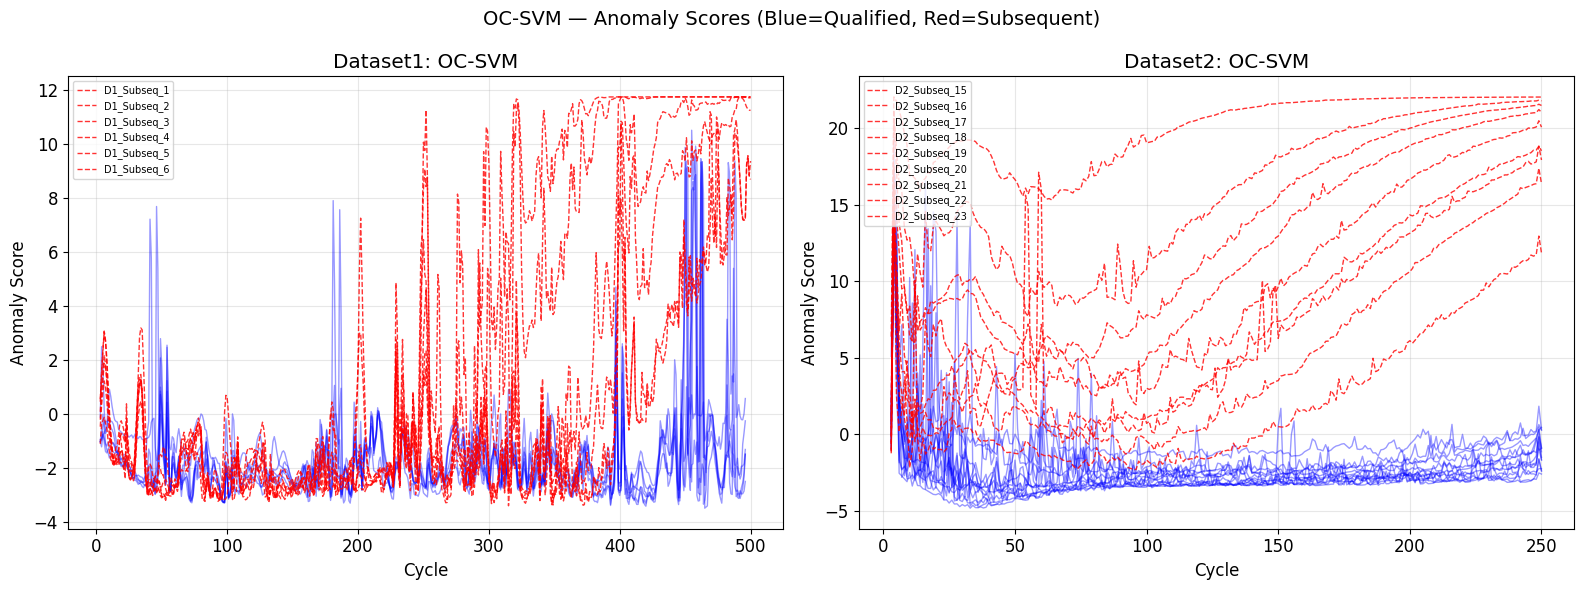

✓ Saved: fig12_ocsvm_scores.png


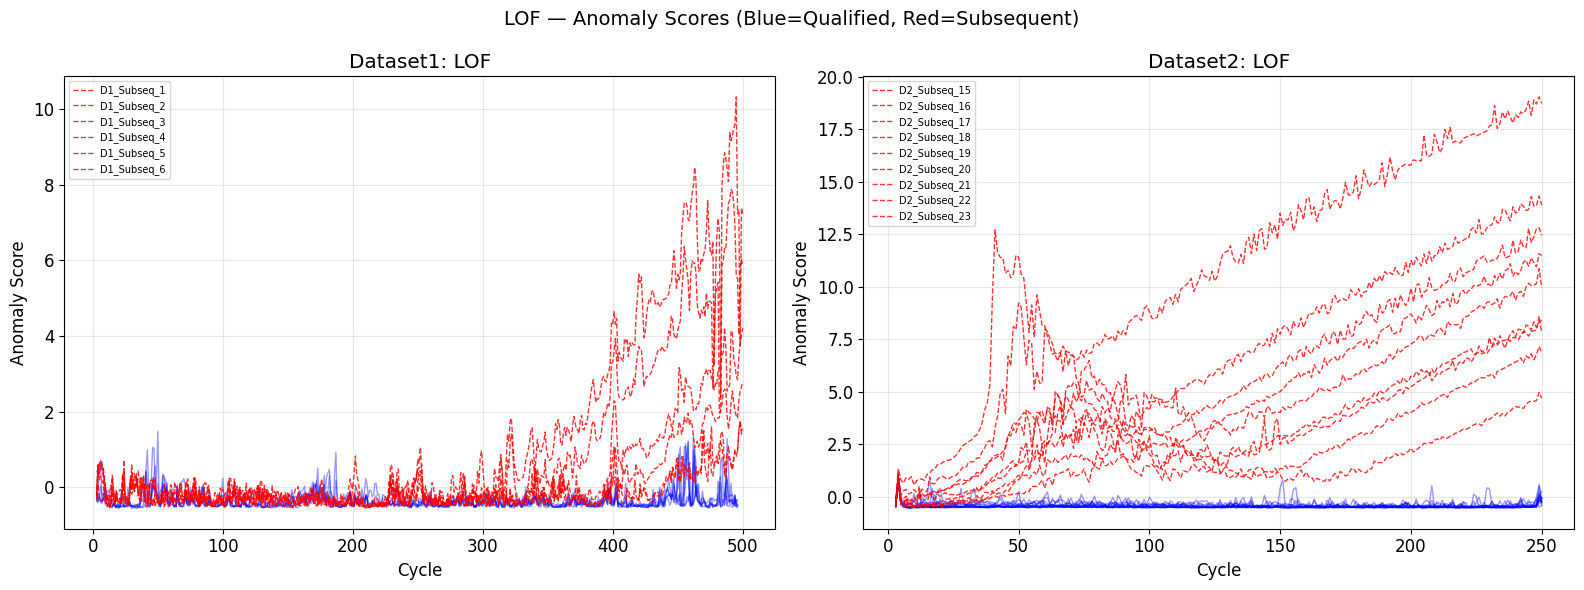

✓ Saved: fig12_lof_scores.png


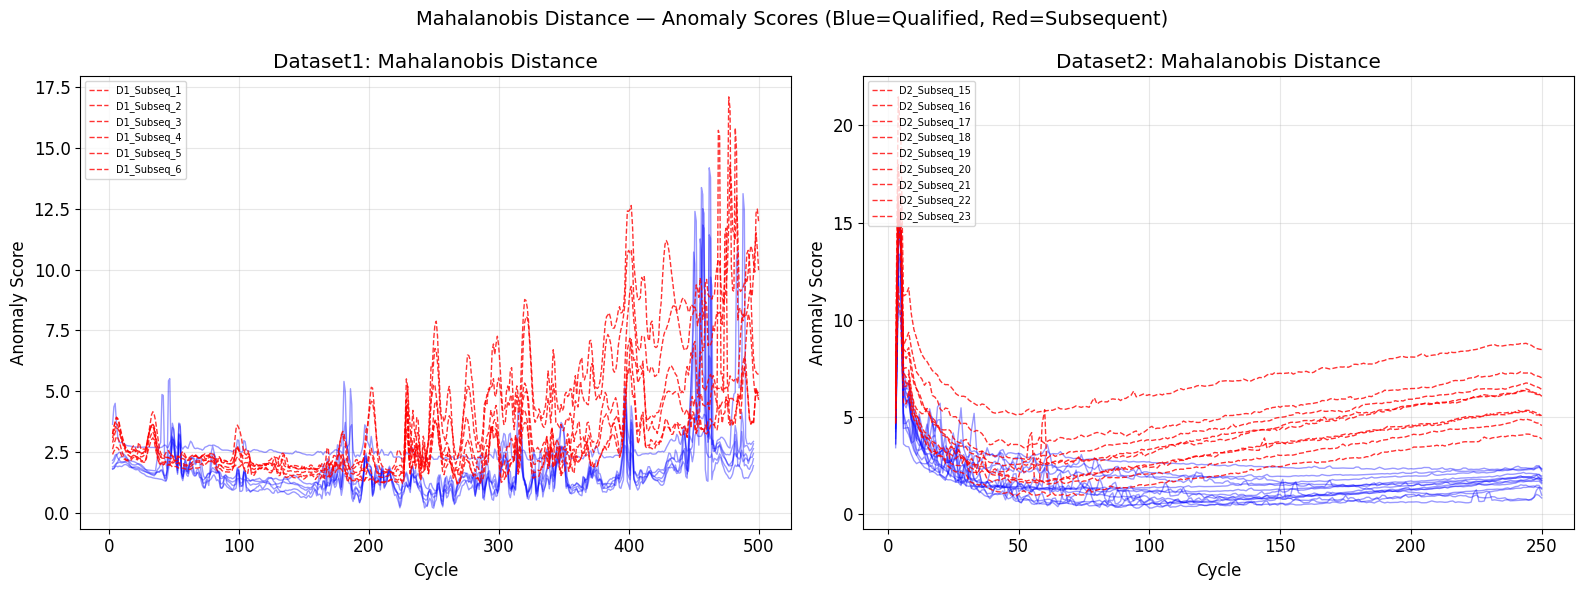

✓ Saved: fig12_mahalanobis_distance_scores.png


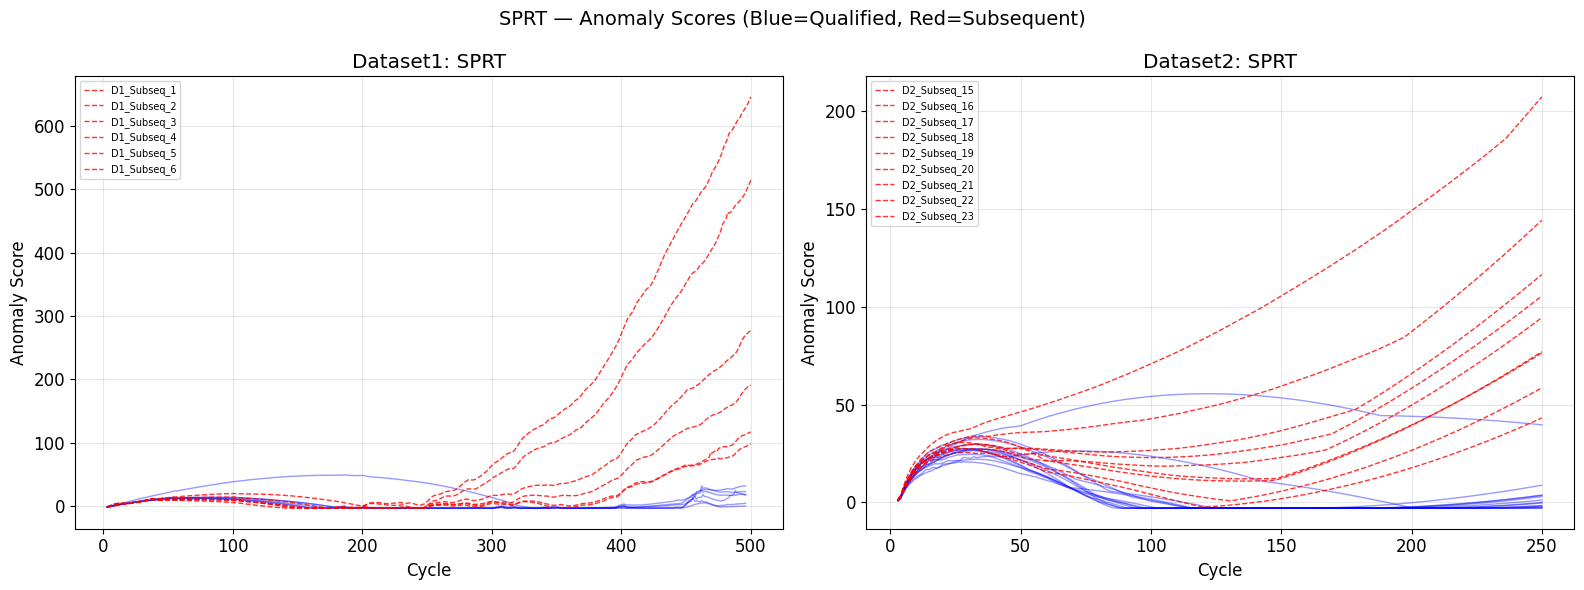

✓ Saved: fig12_sprt_scores.png


In [9]:
def plot_anomaly_scores(results_dict, model_name, save_path=None):
 """
 Plot per-cycle anomaly scores for all cells across both datasets.
 """
 fig, axes = plt.subplots(1, 2, figsize=(16, 6))

 for idx, ds in enumerate(["Dataset1", "Dataset2"]):
 ax = axes[idx]
 results = results_dict[ds]

 for cell_id, res in sorted(results.items()):
 color = "blue" if res["group"] == "Qualified" else "red"
 ls = "-" if res["group"] == "Qualified" else "--"
 alpha = 0.4 if res["group"] == "Qualified" else 0.8
 ax.plot(res["cycles"], res["scores"],
 color=color, linestyle=ls, alpha=alpha, linewidth=1,
 label=cell_id if res["group"]=="Subsequent" else None)

 ax.set_title(f"{ds}: {model_name}")
 ax.set_xlabel("Cycle")
 ax.set_ylabel("Anomaly Score")
 ax.legend(fontsize=7, loc="upper left")

 plt.suptitle(f"{model_name} — Anomaly Scores (Blue=Qualified, Red=Subsequent)",
 fontsize=14)
 plt.tight_layout()
 if save_path:
 plt.savefig(save_path, dpi=150, bbox_inches="tight")
 plt.show()

# Plot all 4 models
models = [
 (ocsvm_results, "OC-SVM"),
 (lof_results, "LOF"),
 (md_results, "Mahalanobis Distance"),
 (sprt_results, "SPRT"),
]

for results, name in models:
 save_path = os.path.join(RESULTS_DIR, f"fig12_{name.lower().replace(" ", "_").replace("-", "")}_scores.png")
 plot_anomaly_scores(results, name, save_path=save_path)
 print(f" Saved: {os.path.basename(save_path)}")

---
## 8. Detection Cycle Estimation

For each model, identify the earliest cycle classified as anomalous.
Threshold: `mean + 3 * std` of the qualified score distribution.


In [10]:
def estimate_detection_cycles(results_dict, method_name):
 """
 Estimate first detection cycle for each cell.
 Threshold = mean + 3*std of all qualified cell scores.
 """
 detection_results = []

 for ds in ["Dataset1", "Dataset2"]:
 results = results_dict[ds]

 # Compute threshold from qualified cells
 qual_scores = np.concatenate([
 res["scores"] for res in results.values()
 if res["group"] == "Qualified"
 ])
 threshold = np.mean(qual_scores) + 3 * np.std(qual_scores)

 for cell_id, res in results.items():
 # Find first cycle where score exceeds threshold for 3+ consecutive cycles
 above = res["scores"] > threshold
 detection_cycle = None

 # Require 3 consecutive cycles above threshold (robustness)
 for i in range(len(above) - 2):
 if above[i] and above[i+1] and above[i+2]:
 detection_cycle = int(res["cycles"][i])
 break

 detection_results.append({
 "dataset": ds,
 "cell_id": cell_id,
 "group": res["group"],
 "method": method_name,
 "detection_cycle": detection_cycle,
 "threshold": threshold,
 "max_score": float(res["scores"].max()),
 })

 return pd.DataFrame(detection_results)

# Compute detection cycles for all methods
all_detections = []
for results, name in models:
 det = estimate_detection_cycles(results, name)
 all_detections.append(det)

detection_df = pd.concat(all_detections, ignore_index=True)

# Show detection cycles for Subsequent cells
subseq_det = detection_df[detection_df["group"] == "Subsequent"]
pivot = subseq_det.pivot_table(
 index=["dataset", "cell_id"], columns="method",
 values="detection_cycle", aggfunc="first"
)
print("=== Detection Cycles (Subsequent Cells) ===")
display(pivot)

# Check false positives (qualified cells detected as anomalous)
qual_det = detection_df[
 (detection_df["group"] == "Qualified") &
 (detection_df["detection_cycle"].notna())
]
print(f"=== False Positives (Qualified cells flagged) ===")
if len(qual_det) > 0:
 display(qual_det[["dataset", "cell_id", "method", "detection_cycle"]])
else:
 print("None — all qualified cells correctly classified as normal.")

=== Detection Cycles (Subsequent Cells) ===


method                   LOF  Mahalanobis Distance  OC-SVM   SPRT
dataset  cell_id                                                 
Dataset1 D1_Subseq_1     4.0                 248.0   248.0  289.0
         D1_Subseq_2     4.0                 250.0    33.0  300.0
         D1_Subseq_3     4.0                 397.0   248.0  369.0
         D1_Subseq_4     4.0                 399.0   398.0  397.0
         D1_Subseq_5   399.0                 399.0   399.0  428.0
         D1_Subseq_6   446.0                 399.0   250.0  429.0
Dataset2 D2_Subseq_15   28.0                   4.0     4.0  219.0
         D2_Subseq_16   37.0                   4.0   151.0  242.0
         D2_Subseq_17   13.0                   3.0     4.0  193.0
         D2_Subseq_18   39.0                 226.0    43.0  204.0
         D2_Subseq_19   12.0                   3.0     4.0  185.0
         D2_Subseq_20    4.0                   3.0     3.0   65.0
         D2_Subseq_21    4.0                   3.0     4.0  133.0
         D2_Subseq_22   43.0                   4.0     4.0    NaN
         D2_Subseq_23   19.0                   4.0     4.0  220.0

=== False Positives (Qualified cells flagged) ===


,dataset,cell_id,method,detection_cycle
0,Dataset1,D1_Qual_1,OC-SVM,455.0
2,Dataset1,D1_Qual_3,OC-SVM,455.0
4,Dataset1,D1_Qual_5,OC-SVM,455.0
5,Dataset1,D1_Qual_6,OC-SVM,449.0
14,Dataset2,D2_Qual_3,OC-SVM,3.0
17,Dataset2,D2_Qual_6,OC-SVM,4.0
20,Dataset2,D2_Qual_9,OC-SVM,4.0
36,Dataset1,D1_Qual_2,LOF,180.0
39,Dataset1,D1_Qual_5,LOF,455.0
40,Dataset1,D1_Qual_6,LOF,3.0


---
## 9. Comparison with Diao 2020 Baselines

Compare our implementations against the detection cycles reported in Diao 2020 (Dataset 1 only).


In [11]:
# Compare our results with Diao 2020
print("=== Diao 2020 Published Baselines (Dataset 1) ===")
display(diao_baselines)

# Our results for D1 Subsequent
our_d1 = detection_df[
    (detection_df["dataset"]=="Dataset1") &
    (detection_df["group"]=="Subsequent")
].pivot_table(
    index="cell_id", columns="method",
    values="detection_cycle", aggfunc="first"
)

print("=== Our Detection Cycles (Dataset 1) ===")
display(our_d1)

# Side-by-side comparison
print("=== Comparison: Diao 2020 (mean across methods) vs Ours ===")
comparison = pd.DataFrame()
for col in diao_baselines.columns:
    cell_id = col
    comparison.loc[cell_id, "Diao_earliest"] = diao_baselines[col].min()
    comparison.loc[cell_id, "Diao_mean"] = diao_baselines[col].mean()
    if cell_id in our_d1.index:
        for method in our_d1.columns:
            comparison.loc[cell_id, f"Ours_{method}"] = our_d1.loc[cell_id, method]

display(comparison)

print("Note: detection at a lower cycle than Diao indicates better early-detection performance.")
print("The goal is for Branch B and Branch C to beat these baseline detection cycles.")


=== Diao 2020 Published Baselines (Dataset 1) ===


,D1_Subseq_1,D1_Subseq_2,D1_Subseq_3,D1_Subseq_4,D1_Subseq_5,D1_Subseq_6
Regression,115,55,139,226,338,277
OC-SVM,110,57,120,153,323,265
LOF,108,56,121,196,322,268
Mahalanobis,109,36,120,212,321,273
SPRT,107,49,119,207,318,269


=== Our Detection Cycles (Dataset 1) ===


method,LOF,Mahalanobis Distance,OC-SVM,SPRT
cell_id,,,,
D1_Subseq_1,4.0,248.0,248.0,289.0
D1_Subseq_2,4.0,250.0,33.0,300.0
D1_Subseq_3,4.0,397.0,248.0,369.0
D1_Subseq_4,4.0,399.0,398.0,397.0
D1_Subseq_5,399.0,399.0,399.0,428.0
D1_Subseq_6,446.0,399.0,250.0,429.0


=== Comparison: Diao 2020 (mean across methods) vs Ours ===


,Diao_earliest,Diao_mean,Ours_LOF,Ours_Mahalanobis Distance,Ours_OC-SVM,Ours_SPRT
D1_Subseq_1,107.0,109.8,4.0,248.0,248.0,289.0
D1_Subseq_2,36.0,50.6,4.0,250.0,33.0,300.0
D1_Subseq_3,119.0,123.8,4.0,397.0,248.0,369.0
D1_Subseq_4,153.0,198.8,4.0,399.0,398.0,397.0
D1_Subseq_5,318.0,324.4,399.0,399.0,399.0,428.0
D1_Subseq_6,265.0,270.4,446.0,399.0,250.0,429.0


→ 우리 모델이 Diao보다 더 빨리(낮은 cycle) 감지하면 early detection 성능 우수
→ 이 baseline 결과를 Branch B/C에서 beat하는 것이 목표


---
## 10. ROC-AUC and PR-AUC Evaluation

Binary classification at the cell level: qualified (0) vs. subsequent (1).
The cell-level score is the maximum per-cycle anomaly score for that cell.


In [12]:
def compute_cell_level_metrics(results_dict, method_name):
 """
 Compute cell-level anomaly scores and binary classification metrics.
 Cell score = max anomaly score across all cycles.
 """
 rows = []
 for ds in ["Dataset1", "Dataset2"]:
 results = results_dict[ds]
 for cell_id, res in results.items():
 rows.append({
 "dataset": ds,
 "cell_id": cell_id,
 "group": res["group"],
 "method": method_name,
 "max_score": float(res["scores"].max()),
 "mean_score": float(res["scores"].mean()),
 "label": 1 if res["group"] == "Subsequent" else 0,
 })
 return pd.DataFrame(rows)

# Compute metrics for all methods
cell_scores = pd.concat([
 compute_cell_level_metrics(results, name)
 for results, name in models
], ignore_index=True)

# ROC-AUC and PR-AUC per dataset per method
print("=== Cell-Level AUC Metrics ===")
auc_results = []
for ds in ["Dataset1", "Dataset2"]:
 for method in cell_scores["method"].unique():
 subset = cell_scores[
 (cell_scores["dataset"]==ds) & (cell_scores["method"]==method)
 ]
 y_true = subset["label"].values
 y_score = subset["max_score"].values

 # ROC-AUC
 try:
 roc = roc_auc_score(y_true, y_score)
 except ValueError:
 roc = np.nan

 # PR-AUC
 try:
 prec, rec, _ = precision_recall_curve(y_true, y_score)
 pr_auc = auc(rec, prec)
 except ValueError:
 pr_auc = np.nan

 auc_results.append({
 "dataset": ds, "method": method,
 "ROC_AUC": roc, "PR_AUC": pr_auc,
 "n_normal": int((y_true==0).sum()),
 "n_anomaly": int((y_true==1).sum()),
 })

auc_df = pd.DataFrame(auc_results)
display(auc_df.round(4))

=== Cell-Level AUC Metrics ===


,dataset,method,ROC_AUC,PR_AUC,n_normal,n_anomaly
0,Dataset1,OC-SVM,0.9722,0.9742,6,6
1,Dataset1,LOF,1.0000,1.0000,6,6
2,Dataset1,Mahalanobis Distance,0.6667,0.7616,6,6
3,Dataset1,SPRT,1.0000,1.0000,6,6
4,Dataset2,OC-SVM,0.9206,0.8984,14,9
5,Dataset2,LOF,1.0000,1.0000,14,9
6,Dataset2,Mahalanobis Distance,0.8254,0.8359,14,9
7,Dataset2,SPRT,0.9921,0.9883,14,9


---
## 11. Summary Comparison

Consolidate every baseline result into a single table.


In [13]:
# --- Combined Summary ---
print("=== Branch A Baseline Summary ===")
print()

# AUC comparison
print("--- Cell-Level AUC ---")
auc_pivot = auc_df.pivot_table(
 index="method", columns="dataset",
 values=["ROC_AUC", "PR_AUC"]
)
display(auc_pivot.round(4))

# Detection cycle comparison (D1 only - has Diao baseline)
print("--- Mean Detection Cycle (D1 Subsequent) ---")
d1_det = detection_df[
 (detection_df["dataset"]=="Dataset1") &
 (detection_df["group"]=="Subsequent") &
 (detection_df["detection_cycle"].notna())
]
if len(d1_det) > 0:
 mean_det = d1_det.groupby("method")["detection_cycle"].mean()
 print(mean_det.round(1))

# Diao 2020 mean for comparison
print(f"Diao 2020 mean detection cycle: {diao_baselines.values.mean():.1f}")
print(f"Diao 2020 earliest per cell: {diao_baselines.min().mean():.1f}")

=== Branch A Baseline Summary ===

--- Cell-Level AUC ---


PR_AUC           ROC_AUC         
dataset              Dataset1 Dataset2 Dataset1 Dataset2
method                                                  
LOF                    1.0000   1.0000   1.0000   1.0000
Mahalanobis Distance   0.7616   0.8359   0.6667   0.8254
OC-SVM                 0.9742   0.8984   0.9722   0.9206
SPRT                   1.0000   0.9883   1.0000   0.9921

--- Mean Detection Cycle (D1 Subsequent) ---
method
LOF                     143.5
Mahalanobis Distance    348.7
OC-SVM                  262.7
SPRT                    368.7
Name: detection_cycle, dtype: float64
Diao 2020 mean detection cycle: 179.6
Diao 2020 earliest per cell:   166.3


---
## 12. Save Results

In [14]:
# --- Save all baseline results ---

# 1. Detection cycles
detection_df.to_csv(os.path.join(PROCESSED_DIR, "baseline_detection_cycles.csv"), index=False)
print(f" baseline_detection_cycles.csv")

# 2. Cell-level scores
cell_scores.to_csv(os.path.join(PROCESSED_DIR, "baseline_cell_scores.csv"), index=False)
print(f" baseline_cell_scores.csv")

# 3. AUC metrics
auc_df.to_csv(os.path.join(PROCESSED_DIR, "baseline_auc_metrics.csv"), index=False)
print(f" baseline_auc_metrics.csv")

# 4. Per-cycle scores (for ensemble later)
baseline_scores = {
 "ocsvm": ocsvm_results,
 "lof": lof_results,
 "mahalanobis": md_results,
 "sprt": sprt_results,
}
with open(os.path.join(PROCESSED_DIR, "baseline_percycle_scores.pkl"), "wb") as f:
 pickle.dump(baseline_scores, f)
print(f" baseline_percycle_scores.pkl")

# 5. Updated features_df with fixed naming
features_df.to_csv(os.path.join(PROCESSED_DIR, "features_all.csv"), index=False)
print(f" features_all.csv (D2 naming fixed)")

# 6. Updated ground truth with fixed naming
gt_d2.to_csv(os.path.join(PROCESSED_DIR, "ground_truth_d2.csv"), index=False)
print(f" ground_truth_d2.csv (D2 naming fixed)")

print(f"=== All saved to {PROCESSED_DIR} ===")
for f in sorted(os.listdir(PROCESSED_DIR)):
 if os.path.isfile(os.path.join(PROCESSED_DIR, f)):
 size = os.path.getsize(os.path.join(PROCESSED_DIR, f)) / 1024
 print(f" {f} ({size:.1f} KB)")

✓ baseline_detection_cycles.csv
✓ baseline_cell_scores.csv
✓ baseline_auc_metrics.csv
✓ baseline_percycle_scores.pkl
✓ features_all.csv (D2 naming fixed)
✓ ground_truth_d2.csv (D2 naming fixed)
=== All saved to /content/drive/MyDrive/battery-anomaly-detection/processed_data ===
  baseline_auc_metrics.csv (0.4 KB)
  baseline_cell_scores.csv (10.9 KB)
  baseline_detection_cycles.csv (11.1 KB)
  baseline_percycle_scores.pkl (464.6 KB)
  diao2020_baselines.csv (0.2 KB)
  features_all.csv (1730.7 KB)
  gaf_images_full.pkl (3363.1 KB)
  gaf_images_progressive.pkl (27560.6 KB)
  ground_truth_d1.csv (0.6 KB)
  ground_truth_d2.csv (1.0 KB)
  sliding_windows.pkl (5707.9 KB)
  smoothed_capacity.pkl (188.2 KB)


---
## 13. Branch A Summary and Next Steps

### Completed
- Unified Dataset 2 naming convention (`D2_Qual_N` / `D2_Subseq_N`)
- Four baseline models implemented: OC-SVM, LOF, Mahalanobis, SPRT
- Per-cycle anomaly scores computed for all cells
- Detection-cycle estimation (mean + 3 * std threshold, 3-consecutive rule)
- Comparison against Diao 2020 baselines
- Cell-level ROC-AUC and PR-AUC evaluation

### Key Results
- Baseline models establish detection-cycle benchmarks for Dataset 1 subsequent cells
- These will be compared against Branch B (deep learning) and Branch C (image-based) models
- Per-cycle scores saved for downstream ensemble evaluation

### Next
- `04_deep_learning.ipynb` -> Branch B: LSTM-AE, TCN-AE, Transformer-AE
- `05_gaf_image_models.ipynb` -> Branch C: PatchCore, CNN-AE, EfficientAD


In [15]:
print("=== Branch A Complete ===")
print("Ready for:")
print(" 04_deep_learning.ipynb -> Branch B (LSTM-AE, TCN-AE, Transformer-AE)")
print(" 05_gaf_image_models.ipynb -> Branch C (PatchCore, CNN-AE, EfficientAD)")

=== Branch A Complete ===
Ready for:
  04_deep_learning.ipynb   → Branch B (LSTM-AE, TCN-AE, Transformer-AE)
  05_gaf_image_models.ipynb → Branch C (PatchCore, CNN-AE, EfficientAD)
